# Task 10 - Camera Calibration and Lens Undistortion

## Objective

The objective of this task is to estimate the intrinsic parameters of the camera using multiple checkerboard images.

The calibration parameters are then used to remove lens distortion from a photograph containing straight lines, demonstrating the effect of camera calibration.

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob

In [2]:
CHECKERBOARD = (9,6)

In [3]:
objp = np.zeros((CHECKERBOARD[0] * CHECKERBOARD[1], 3), np.float32)
objp[:, :2] = np.mgrid[0:CHECKERBOARD[0], 0:CHECKERBOARD[1]].T.reshape(-1, 2)

objpoints = []
imgpoints = []

In [4]:
images = glob.glob("../raw_captures/calibration/*.jpeg")

print("Images Found:", len(images))

Images Found: 15


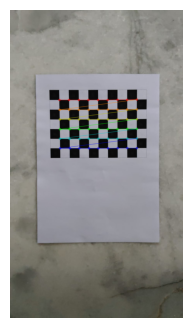

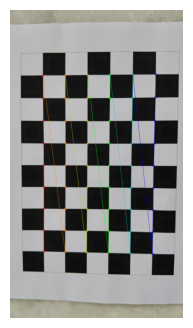

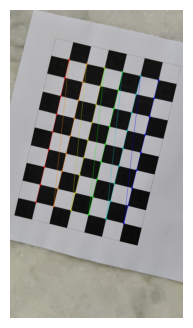

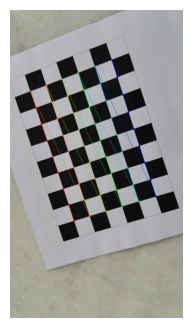

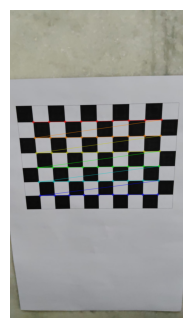

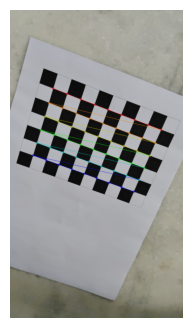

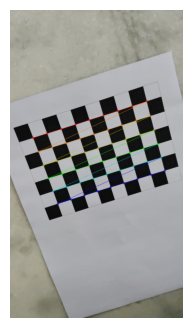

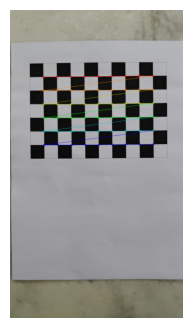

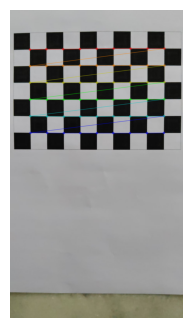

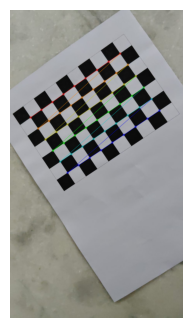

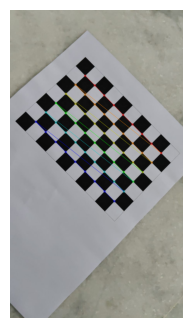

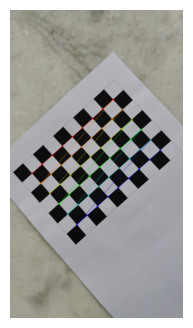

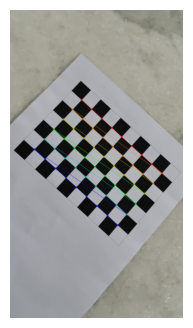

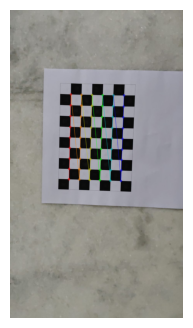

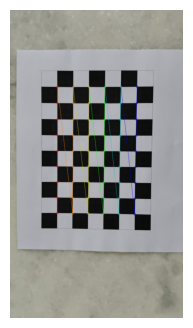

In [5]:
for fname in images:

    img = cv2.imread(fname)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    ret, corners = cv2.findChessboardCorners(gray, CHECKERBOARD, None)

    if ret:

        objpoints.append(objp)

        corners2 = cv2.cornerSubPix(
            gray,
            corners,
            (11,11),
            (-1,-1),
            (
                cv2.TERM_CRITERIA_EPS +
                cv2.TERM_CRITERIA_MAX_ITER,
                30,
                0.001
            )
        )

        imgpoints.append(corners2)

        cv2.drawChessboardCorners(
            img,
            CHECKERBOARD,
            corners2,
            ret
        )

        plt.figure(figsize=(5,4))
        plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
        plt.axis("off")
        plt.show()

In [6]:
print("Valid checkerboards:", len(objpoints))

ret, cameraMatrix, distCoeffs, rvecs, tvecs = cv2.calibrateCamera(
    objpoints,
    imgpoints,
    gray.shape[::-1],
    None,
    None
)

Valid checkerboards: 15


In [7]:
print("Camera Matrix:\n")
print(cameraMatrix)

print("\nDistortion Coefficients:\n")
print(distCoeffs)

fx = cameraMatrix[0,0]
fy = cameraMatrix[1,1]

cx = cameraMatrix[0,2]
cy = cameraMatrix[1,2]

print("\nfx =", fx)
print("fy =", fy)
print("cx =", cx)
print("cy =", cy)

Camera Matrix:

[[1.43210165e+03 0.00000000e+00 4.38597223e+02]
 [0.00000000e+00 1.43422886e+03 8.31115085e+02]
 [0.00000000e+00 0.00000000e+00 1.00000000e+00]]

Distortion Coefficients:

[[ 0.22620458 -0.77538381  0.0034171  -0.00238053  0.51614517]]

fx = 1432.1016549653127
fy = 1434.228861929378
cx = 438.59722302295086
cy = 831.1150845273665


In [8]:
mean_error = 0

for i in range(len(objpoints)):

    imgpoints2, _ = cv2.projectPoints(
        objpoints[i],
        rvecs[i],
        tvecs[i],
        cameraMatrix,
        distCoeffs
    )

    img1 = imgpoints[i].reshape(-1, 2).astype(np.float32)
    img2 = imgpoints2.reshape(-1, 2).astype(np.float32)

    error = cv2.norm(img1, img2, cv2.NORM_L2) / len(img2)

    mean_error += error

print("Reprojection Error:", mean_error / len(objpoints))

Reprojection Error: 0.06963390004408557


In [9]:
img = cv2.imread("../raw_captures/distorted_scene.jpeg")

h, w = img.shape[:2]

newCameraMatrix, roi = cv2.getOptimalNewCameraMatrix(
    cameraMatrix,
    distCoeffs,
    (w,h),
    1,
    (w,h)
)

undistorted = cv2.undistort(
    img,
    cameraMatrix,
    distCoeffs,
    None,
    newCameraMatrix
)

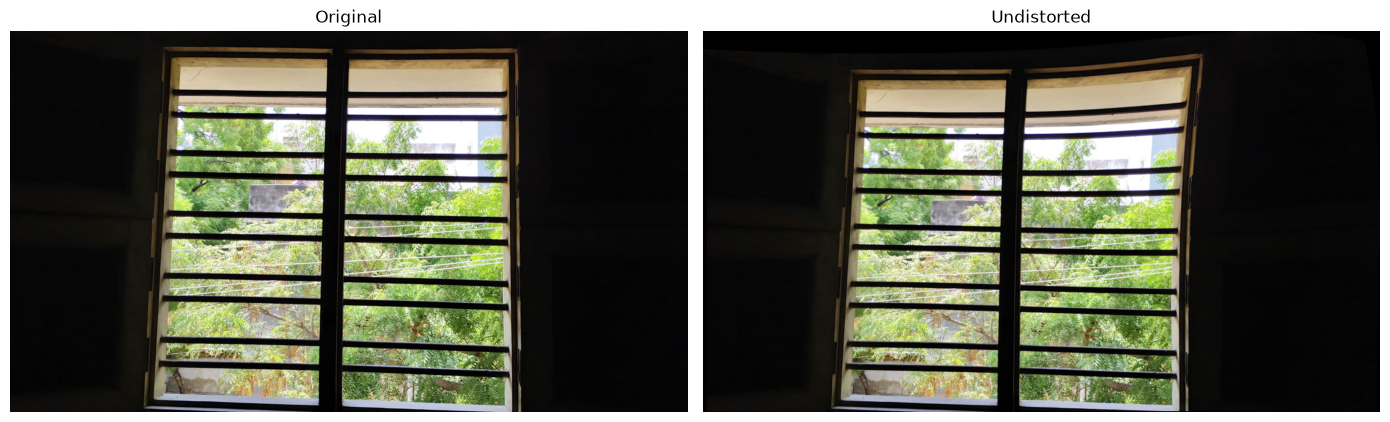

In [10]:
plt.figure(figsize=(14,6))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(undistorted, cv2.COLOR_BGR2RGB))
plt.title("Undistorted")
plt.axis("off")

plt.tight_layout()
plt.show()

## Observations

- A total of **15** checkerboard images were captured.
- **2** images were discarded because the checkerboard corners could not be detected due to glare and motion blur.
- The remaining images were successfully used for camera calibration.

### Calibration Results

- Focal Length (fx): **XXXX**
- Focal Length (fy): **XXXX**
- Principal Point (cx): **XXXX**
- Principal Point (cy): **XXXX**
- Reprojection Error: **XXXX**

### Undistortion

The undistorted image showed straighter lines near the edges of the frame compared to the original image, indicating that the computed calibration parameters effectively reduced lens distortion.

### Conclusion

Camera calibration accurately estimated the intrinsic parameters of the camera. These parameters were successfully used to remove lens distortion and improve the geometric accuracy of the captured image.